## Building a fuzzy expert system considers challenges of post war building assessments

In [19]:
# ! pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [20]:
# Step 1: Specify the problem and define linguistic variables
def define_variables():
    print("Defining linguistic variables and their fuzzy sets...")

    structural_safety = ctrl.Antecedent(np.arange(0, 14, 1), 'structural_safety')
    damage_type = ctrl.Antecedent(np.arange(0, 14, 1), 'damage_type')
    repair_cost = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'repair_cost')
    repair_time = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'repair_time')
    risk_factor = ctrl.Antecedent(np.arange(0, 10, 1), 'risk_factor')
    structural_factor = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'structural_factor')
    partial_damage_level = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'partial_damage_level')
    total_damage = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'total_damage')
    risk_level = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'risk_level')
    recommendation = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'recommendation')

    # Define fuzzy sets for each variable
    structural_safety['Unknown'] = fuzz.trimf(structural_safety.universe, [0, 0, 0])
    structural_safety['Primary Column'] = fuzz.trimf(structural_safety.universe, [1, 1, 1])
    structural_safety['Secondary Column'] = fuzz.trimf(structural_safety.universe, [2, 2, 2])
    structural_safety['Foundation'] = fuzz.trimf(structural_safety.universe, [3, 3, 3])
    structural_safety['Ceiling'] = fuzz.trimf(structural_safety.universe, [4, 4, 4])
    structural_safety['Wall'] = fuzz.trimf(structural_safety.universe, [5, 5, 5])
    structural_safety['Floor'] = fuzz.trimf(structural_safety.universe, [6, 6, 6])
    structural_safety['Staircase'] = fuzz.trimf(structural_safety.universe, [7, 7, 7])
    structural_safety['Water Pipe'] = fuzz.trimf(structural_safety.universe, [8, 8, 8])
    structural_safety['Sewage Pipe'] = fuzz.trimf(structural_safety.universe, [9, 9, 9])
    structural_safety['Electrical Network'] = fuzz.trimf(structural_safety.universe, [10, 10, 10])
    structural_safety['Door'] = fuzz.trimf(structural_safety.universe, [11, 11, 11])
    structural_safety['Window'] = fuzz.trimf(structural_safety.universe, [12, 12, 12])
    structural_safety['Fence'] = fuzz.trimf(structural_safety.universe, [13, 13, 13])

    damage_type['Unknown'] = fuzz.trimf(damage_type.universe, [0, 0, 0])
    damage_type['Major Crack'] = fuzz.trimf(damage_type.universe, [1, 1, 1])
    damage_type['Partial Collapse'] = fuzz.trimf(damage_type.universe, [2, 2, 2])
    damage_type['Significant Tilt'] = fuzz.trimf(damage_type.universe, [3, 3, 3])
    damage_type['Major Leak'] = fuzz.trimf(damage_type.universe, [4, 4, 4])
    damage_type['Severe Corrosion'] = fuzz.trimf(damage_type.universe, [5, 5, 5])
    damage_type['Heavy Rust'] = fuzz.trimf(damage_type.universe, [6, 6, 6])
    damage_type['Minor Crack'] = fuzz.trimf(damage_type.universe, [7, 7, 7])
    damage_type['Minor Leak'] = fuzz.trimf(damage_type.universe, [8, 8, 8])
    damage_type['Mild Corrosion'] = fuzz.trimf(damage_type.universe, [9, 9, 9])
    damage_type['Light Rust'] = fuzz.trimf(damage_type.universe, [10, 10, 10])
    damage_type['Partial Settlement'] = fuzz.trimf(damage_type.universe, [11, 11, 11])
    damage_type['Mild Tilt'] = fuzz.trimf(damage_type.universe, [12, 12, 12])
    damage_type['No Damage'] = fuzz.trimf(damage_type.universe, [13, 13, 13])

    repair_cost['Very High'] = fuzz.trimf(repair_cost.universe, [0.8, 0.9, 1])
    repair_cost['High'] = fuzz.trimf(repair_cost.universe, [0.6, 0.7, 0.8])
    repair_cost['Medium'] = fuzz.trimf(repair_cost.universe, [0.4, 0.5, 0.6])
    repair_cost['Low'] = fuzz.trimf(repair_cost.universe, [0.2, 0.3, 0.4])
    repair_cost['Very Low'] = fuzz.trimf(repair_cost.universe, [0, 0, 0.2])
    repair_cost['Unknown'] = fuzz.trimf(repair_cost.universe, [0, 0, 0])

    repair_time['Very Long'] = fuzz.trimf(repair_time.universe, [0.8, 0.9, 1])
    repair_time['Long'] = fuzz.trimf(repair_time.universe, [0.6, 0.7, 0.8])
    repair_time['Medium'] = fuzz.trimf(repair_time.universe, [0.4, 0.5, 0.6])
    repair_time['Short'] = fuzz.trimf(repair_time.universe, [0.2, 0.3, 0.4])
    repair_time['Very Short'] = fuzz.trimf(repair_time.universe, [0, 0, 0.2])
    repair_time['Unknown'] = fuzz.trimf(repair_time.universe, [0, 0, 0])

    risk_factor['Unknown'] = fuzz.trimf(risk_factor.universe, [0, 0, 0])
    risk_factor['Unexploded Ordnance'] = fuzz.trimf(risk_factor.universe, [1, 1, 1])
    risk_factor['Large Hanging Debris'] = fuzz.trimf(risk_factor.universe, [2, 2, 2])
    risk_factor['Active Fire'] = fuzz.trimf(risk_factor.universe, [3, 3, 3])
    risk_factor['Imminent Collapse'] = fuzz.trimf(risk_factor.universe, [4, 4, 4])
    risk_factor['Inactive Ordnance'] = fuzz.trimf(risk_factor.universe, [5, 5, 5])
    risk_factor['Small Hanging Debris'] = fuzz.trimf(risk_factor.universe, [6, 6, 6])
    risk_factor['Stable Fire Residues'] = fuzz.trimf(risk_factor.universe, [7, 7, 7])
    risk_factor['Uncertain Collapse'] = fuzz.trimf(risk_factor.universe, [8, 8, 8])
    risk_factor['No Risk Factors'] = fuzz.trimf(risk_factor.universe, [9, 9, 9])

    structural_factor['Main'] = fuzz.trimf(structural_factor.universe, [0.8, 0.9, 1])
    structural_factor['Secondary'] = fuzz.trimf(structural_factor.universe, [0.4, 0.6, 0.8])
    structural_factor['Supplementary'] = fuzz.trimf(structural_factor.universe, [0, 0.2, 0.4])
    structural_factor['Unknown'] = fuzz.trimf(structural_factor.universe, [0, 0, 0])

    partial_damage_level['Deep'] = fuzz.trimf(partial_damage_level.universe, [0.7, 0.9, 1])
    partial_damage_level['Surface'] = fuzz.trimf(partial_damage_level.universe, [0.3, 0.5, 0.7])
    partial_damage_level['Nothing'] = fuzz.trimf(partial_damage_level.universe, [0, 0.1, 0.3])
    partial_damage_level['Unknown'] = fuzz.trimf(partial_damage_level.universe, [0, 0, 0])

    total_damage['Severe'] = fuzz.trimf(total_damage.universe, [0.7, 0.85, 1])
    total_damage['Moderate'] = fuzz.trimf(total_damage.universe, [0.4, 0.6, 0.8])
    total_damage['Minor'] = fuzz.trimf(total_damage.universe, [0.2, 0.35, 0.5])
    total_damage['Safe'] = fuzz.trimf(total_damage.universe, [0, 0.1, 0.2])
    total_damage['Unknown'] = fuzz.trimf(total_damage.universe, [0, 0, 0])

    risk_level['High'] = fuzz.trimf(risk_level.universe, [0.7, 0.85, 1])
    risk_level['Medium'] = fuzz.trimf(risk_level.universe, [0.4, 0.6, 0.8])
    risk_level['Low'] = fuzz.trimf(risk_level.universe, [0.2, 0.35, 0.5])
    risk_level['Safe'] = fuzz.trimf(risk_level.universe, [0, 0.1, 0.2])
    risk_level['Unknown'] = fuzz.trimf(risk_level.universe, [0, 0, 0])

    recommendation['Immediate evacuation and no entry, followed by demolition and reconstruction'] = fuzz.trimf(recommendation.universe, [0.9, 1, 1])
    recommendation['Temporary evacuation and securing the site, followed by demolition and reconstruction'] = fuzz.trimf(recommendation.universe, [0.8, 0.9, 1])
    recommendation['Evacuate affected areas, monitor using drones, and perform urgent repairs'] = fuzz.trimf(recommendation.universe, [0.7, 0.8, 0.9])
    recommendation['Immediate evacuation and the use of drones for assessment'] = fuzz.trimf(recommendation.universe, [0.6, 0.7, 0.8])
    recommendation['Secure and monitor the site using drones, and perform repairs as soon as possible'] = fuzz.trimf(recommendation.universe, [0.5, 0.6, 0.7])
    recommendation['Comprehensive repair before use'] = fuzz.trimf(recommendation.universe, [0.4, 0.5, 0.6])
    recommendation['Perform minor repairs to prevent increased risk'] = fuzz.trimf(recommendation.universe, [0.3, 0.4, 0.5])
    recommendation['Perform routine maintenance and minor improvements'] = fuzz.trimf(recommendation.universe, [0.2, 0.3, 0.4])
    recommendation['Minimize the use of the building to the bare minimum and conduct an additional assessment of the risk level'] = fuzz.trimf(recommendation.universe, [0.1, 0.2, 0.3])
    recommendation['Regular use without restrictions'] = fuzz.trimf(recommendation.universe, [0, 0.1, 0.2])
    recommendation['Continue usage with regular site monitoring and risk assessment'] = fuzz.trimf(recommendation.universe, [0.1, 0.2, 0.3])
    recommendation['Unknown'] = fuzz.trimf(recommendation.universe, [0, 0, 0])

    print("Linguistic variables and fuzzy sets defined successfully.")
    return structural_safety, damage_type, repair_cost, repair_time, risk_factor, structural_factor, partial_damage_level, total_damage, risk_level, recommendation

In [21]:
# Get linguistic variable labels
def get_output_label(fuzzy_sets, output_value, universe):
    for label, fuzzy_set in fuzzy_sets.items():
        # Evaluate the membership function of the fuzzy set for the output_value
        membership_value = fuzz.interp_membership(universe, fuzzy_set.mf, output_value)
        if membership_value > 0:  # Check if the value belongs to this fuzzy set
            return label
    return None  # Return None if no matching fuzzy set is found

def get_label(simulation, target):
    fuzzy_sets = target.terms
    extracted_value = str(target).split(':')[1].strip()
    output_value = simulation.output[f'{extracted_value}']
    output_label = get_output_label(fuzzy_sets, output_value, target.universe)
    return output_label


In [22]:
# Step 2: Determine and visualize fuzzy sets
def visualize_system(structural_factor, partial_damage_level, total_damage, risk_level, recommendation, simulation):
    print("Visualizing the fuzzy system...")

    structural_factor.view(sim=simulation)
    partial_damage_level.view(sim=simulation)
    total_damage.view(sim=simulation)
    risk_level.view(sim=simulation)

    recommendation.view(sim=simulation)

    # Get the current axis of the plot
    ax = plt.gca()

    # Clear all the previous legends
    ax.legend_.remove()

    # Show the plot
    plt.tight_layout()
    plt.show()

In [23]:
# Step 3: Elicit and construct fuzzy rules
def construct_rules(structural_safety, damage_type, repair_cost, repair_time, risk_factor, structural_factor, partial_damage_level, total_damage, risk_level, recommendation):
    print("Constructing fuzzy rules...")

    # Structural Safety Factor:
    rule1 = ctrl.Rule(structural_safety['Primary Column'] | structural_safety['Secondary Column'] | structural_safety['Foundation'] | structural_safety['Ceiling'], structural_factor['Main'])
    rule2 = ctrl.Rule(structural_safety['Wall'] | structural_safety['Floor'] | structural_safety['Staircase'] | structural_safety['Water Pipe'] | structural_safety['Sewage Pipe'] | structural_safety['Electrical Network'], structural_factor['Secondary'])
    rule3 = ctrl.Rule(structural_safety['Door'] | structural_safety['Window'] | structural_safety['Fence'], structural_factor['Supplementary'])

    # Damage Type:
    rule4 = ctrl.Rule(damage_type['Major Crack'] | damage_type['Partial Collapse'] | damage_type['Significant Tilt'] | damage_type['Major Leak'] | damage_type['Severe Corrosion'] | damage_type['Heavy Rust'], partial_damage_level['Deep'])
    rule5 = ctrl.Rule(damage_type['Minor Crack'] | damage_type['Minor Leak'] | damage_type['Mild Corrosion'] | damage_type['Light Rust'] | damage_type['Partial Settlement'] | damage_type['Mild Tilt'], partial_damage_level['Surface'])
    rule6 = ctrl.Rule(damage_type['No Damage'], partial_damage_level['Nothing'])

    # Total Damage Based on Structural Factor and Damage Level:
    if partial_damage_level is not None and partial_damage_level != 'Unknown': # Handling uncertainty
        rule7 = ctrl.Rule(structural_factor['Main'] & partial_damage_level['Deep'], total_damage['Severe'])
    else:
        rule7 = ctrl.Rule(structural_factor['Main'], total_damage['Severe'])
    rule8 = ctrl.Rule(structural_factor['Main'] & partial_damage_level['Surface'], total_damage['Moderate'])
    rule9 = ctrl.Rule(structural_factor['Secondary'] & partial_damage_level['Deep'], total_damage['Moderate'])
    if partial_damage_level is not None and partial_damage_level != 'Unknown': # Handling uncertainty
        rule10 = ctrl.Rule(structural_factor['Secondary'] & partial_damage_level['Surface'], total_damage['Minor'])
    else:
        rule10 = ctrl.Rule(structural_factor['Secondary'], total_damage['Minor'])
    rule11 = ctrl.Rule(structural_factor['Supplementary'] & partial_damage_level['Deep'], total_damage['Minor'])
    rule12 = ctrl.Rule(structural_factor['Supplementary'] & partial_damage_level['Surface'], total_damage['Safe'])
    if partial_damage_level is not None and partial_damage_level != 'Unknown': # Handling uncertainty
        rule13 = ctrl.Rule(structural_factor['Supplementary'] & partial_damage_level['Nothing'], total_damage['Safe'])
    else:
        rule13 = ctrl.Rule(structural_factor['Supplementary'], total_damage['Safe'])

    # Total Damage Based on Repair Cost and Time:
    if repair_time is not None and repair_time != 'Unknown': # Handling uncertainty
        rule14 = ctrl.Rule(repair_cost['Very High'] & repair_time['Very Long'], total_damage['Severe'])
    else:
        rule14 = ctrl.Rule(repair_cost['Very High'], total_damage['Severe'])
    rule15 = ctrl.Rule(repair_cost['High'] & repair_time['Long'], total_damage['Moderate'])
    rule16 = ctrl.Rule(repair_cost['Medium'] & repair_time['Long'], total_damage['Moderate'])
    rule17 = ctrl.Rule(repair_cost['Low'] & repair_time['Medium'], total_damage['Minor'])
    rule18 = ctrl.Rule(repair_cost['Low'] & repair_time['Short'] & partial_damage_level['Surface'], total_damage['Safe'])
    rule19 = ctrl.Rule(repair_cost['Very High'] & repair_time['Medium'] & partial_damage_level['Deep'], total_damage['Severe'])
    rule20 = ctrl.Rule(repair_cost['Medium'] & repair_time['Very Long'] & partial_damage_level['Surface'], total_damage['Moderate'])
    rule21 = ctrl.Rule(repair_cost['High'] & repair_time['Medium'] & partial_damage_level['Deep'], total_damage['Severe'])

    # Risk Level Based on Risk Factor:
    rule22 = ctrl.Rule(risk_factor['Unexploded Ordnance'] | risk_factor['Large Hanging Debris'] | risk_factor['Active Fire'] | risk_factor['Imminent Collapse'], risk_level['High'])
    rule23 = ctrl.Rule(risk_factor['Inactive Ordnance'] | risk_factor['Small Hanging Debris'] | risk_factor['Stable Fire Residues'] | risk_factor['Uncertain Collapse'], risk_level['Medium'])
    rule24 = ctrl.Rule(risk_factor['No Risk Factors'], risk_level['Safe'])

    # Risk Level Based on Structural Factor and Partial Damage Level:
    rule25 = ctrl.Rule(structural_factor['Main'] & partial_damage_level['Nothing'], risk_level['High'])
    if partial_damage_level is None or partial_damage_level == 'Unknown': # Handling uncertainty
        rule26 = ctrl.Rule(structural_factor['Secondary'], risk_level['Low'])
    else:
        rule26 = ctrl.Rule(structural_factor['Secondary'] & partial_damage_level['Nothing'], risk_level['Safe'])
    if partial_damage_level is not None and partial_damage_level != 'Unknown': # Handling uncertainty
        rule27 = ctrl.Rule(structural_factor['Supplementary'] & partial_damage_level['Nothing'], risk_level['Safe'])
    else:
        rule27 = ctrl.Rule(structural_factor['Supplementary'], risk_level['Safe'])


    # Recommendations Based on Total Damage and Risk Level:
    rule28 = ctrl.Rule(total_damage['Severe'] & risk_level['High'], recommendation['Immediate evacuation and no entry, followed by demolition and reconstruction'])
    rule29 = ctrl.Rule(total_damage['Severe'] & risk_level['Medium'], recommendation['Temporary evacuation and securing the site, followed by demolition and reconstruction'])
    if total_damage is not None and total_damage != 'Unknown': # Handling uncertainty
        rule30 = ctrl.Rule(total_damage['Moderate'] & risk_level['High'], recommendation['Evacuate affected areas, monitor using drones, and perform urgent repairs'])
    else:
        rule30 = ctrl.Rule(risk_level['High'], recommendation['Immediate evacuation and the use of drones for assessment'])
    rule31 = ctrl.Rule(total_damage['Moderate'] & risk_level['Medium'], recommendation['Secure and monitor the site using drones, and perform repairs as soon as possible'])
    rule32 = ctrl.Rule(total_damage['Minor'] & risk_level['Safe'], recommendation['Perform routine maintenance and minor improvements'])
    rule33 = ctrl.Rule(total_damage['Safe'] & risk_level['Safe'], recommendation['Regular use without restrictions'])
    if risk_level is not None and risk_level != 'Unknown': # Handling uncertainty
        rule34 = ctrl.Rule(total_damage['Moderate'] & risk_level['Safe'], recommendation['Comprehensive repair before use'])
    else:
        rule34 = ctrl.Rule(total_damage['Moderate'], recommendation['Minimize the use of the building to the bare minimum and conduct an additional assessment of the risk level'])
    if risk_level is not None and risk_level != 'Unknown': # Handling uncertainty
        rule35 = ctrl.Rule(total_damage['Minor'] & risk_level['High'], recommendation['Perform minor repairs to prevent increased risk'])
    else:
        rule35 = ctrl.Rule(total_damage['Minor'], recommendation['Continue usage with regular site monitoring and risk assessment'])


    print("Fuzzy rules constructed successfully.")
    return [rule1 ,rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
            rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27, rule28, rule29, rule30, rule31, rule32, rule33, rule34, rule35]


In [24]:
# Step 4: Encode fuzzy sets and rules into the expert system
def create_fuzzy_system(rules):
    print("Creating the fuzzy expert system...")
    # Define the control system
    control_system = ctrl.ControlSystem(rules)
    simulation = ctrl.ControlSystemSimulation(control_system)
    print("Fuzzy expert system created successfully.")
    return simulation

In [25]:
# Test the system using 4 different cases if the user input invalid value
test_cases = [
    # {'structural_safety': 'Door', 'damage_type': 'No Damage', 'repair_cost': 'Very Low', 'repair_time': 'Very Short', 'risk_factor': 'No Risk Factors'}, # Low Demand Scenario (Safe)
    # {'structural_safety': 'Wall', 'damage_type': 'Mild Corrosion', 'repair_cost': 'Low', 'repair_time': 'Short', 'risk_factor': 'No Risk Factors'}, # Low Demand Scenario (Minor)
    {'structural_safety': 'Staircase', 'damage_type': 'Minor Crack', 'repair_cost': 'Medium', 'repair_time': 'Long', 'risk_factor': 'Inactive Ordnance'}, # Moderate Demand Scenario (Moderate)
    {'structural_safety': 'Primary Column', 'damage_type': 'Major Leak', 'repair_cost': 'Unknown', 'repair_time': 'Very Long', 'risk_factor': 'Unexploded Ordnance'} # High Demand Scenario (Severe)
]

In [26]:
# Step 5: Evaluate and tune the fuzzy expert system
def evaluate_system(simulation):
    print("Evaluating the fuzzy expert system...")

    try:
        choice = input("Do you want to enter a string or numeric values? (enter 1 to string and 2 to numeric)")
        if choice == "1":
            structural_safety_input = float(input("Enter structural safety: "))
            structural_safety_input = structural_safety[f'{structural_safety_input}']
            damage_type_input = float(input("Enter damage type: "))
            damage_type_input = damage_type[f'{damage_type_input}']
            repair_cost_input = float(input("Enter repair cost: "))
            repair_cost_input = repair_cost[f'{repair_cost_input}']
            repair_time_input = float(input("Enter repair time: "))
            repair_time_input = repair_time[f'{repair_time_input}']
            risk_factor_input = float(input("Enter risk factor: "))
            risk_factor_input = risk_factor[f'{risk_factor_input}']
        elif choice == "2":
            structural_safety_input = float(input("Enter structural safety (0 to 12): "))
            damage_type_input = float(input("Enter damage type (0 to 12): "))
            repair_cost_input = float(input("Enter repair cost (0 to 1): "))
            repair_time_input = float(input("Enter repair time (0 to 1): "))
            risk_factor_input = float(input("Enter risk factor (0 to 8): "))

        simulation.input['structural_safety'] = structural_safety_input
        simulation.input['damage_type'] = damage_type_input
        simulation.input['repair_cost'] = repair_cost_input
        simulation.input['repair_time'] = repair_time_input
        simulation.input['risk_factor'] = risk_factor_input

        # Compute the output
        simulation.compute()
        total_damage_label = get_label(simulation, total_damage)
        recommendation_label = get_label(simulation, recommendation)

        # Print the output results
        print("Simulation results...")
        print(f"Total Damage Level (Ratio): {simulation.output['total_damage']:.2f}")
        print(f"Recommendation (Ratio): {simulation.output['recommendation']:.2f}")
        print(f"Total Damage Level: {total_damage_label}")
        print(f"Recommendation: {recommendation_label}")

    except:
        print('Test the system using 4 different cases...')
        case_num = 0
        for case in test_cases:
            case_num += 1
            print(f"Test case {case_num}: {case}")
            structural_safety_input = structural_safety[case['structural_safety']]
            damage_type_input = damage_type[case['damage_type']]
            repair_cost_input = repair_cost[case['repair_cost']]
            repair_time_input = repair_time[case['repair_time']]
            risk_factor_input = risk_factor[case['risk_factor']]

            simulation.input['structural_safety'] = structural_safety_input
            simulation.input['damage_type'] = damage_type_input
            simulation.input['repair_cost'] = repair_cost_input
            simulation.input['repair_time'] = repair_time_input
            simulation.input['risk_factor'] = risk_factor_input

            # Compute the output
            simulation.compute()
            total_damage_label = get_label(simulation, total_damage)
            recommendation_label = get_label(simulation, recommendation)

            # Print the output results
            print("Simulation results...")
            print(f"Total Damage Level (Ratio): {simulation.output['total_damage']:.2f}")
            print(f"Recommendation (Ratio): {simulation.output['recommendation']:.2f}")
            print(f"Total Damage Level: {total_damage_label}")
            print(f"Recommendation: {recommendation_label}")

    return simulation

Initializing the fuzzy expert system for post-war building assessments...
Defining linguistic variables and their fuzzy sets...
Linguistic variables and fuzzy sets defined successfully.
Constructing fuzzy rules...
Fuzzy rules constructed successfully.
Creating the fuzzy expert system...
Fuzzy expert system created successfully.
Evaluating the fuzzy expert system...
Test the system using 4 different cases...
Test case 1: {'structural_safety': 'Staircase', 'damage_type': 'Minor Crack', 'repair_cost': 'Medium', 'repair_time': 'Long', 'risk_factor': 'Inactive Ordnance'}
Simulation results...
Total Damage Level (Ratio): 0.50
Recommendation (Ratio): 0.60
Total Damage Level: Moderate
Recommendation: Immediate evacuation and the use of drones for assessment
Test case 2: {'structural_safety': 'Primary Column', 'damage_type': 'Major Leak', 'repair_cost': 'Unknown', 'repair_time': 'Very Long', 'risk_factor': 'Unexploded Ordnance'}
Simulation results...
Total Damage Level (Ratio): 0.85
Recommendat

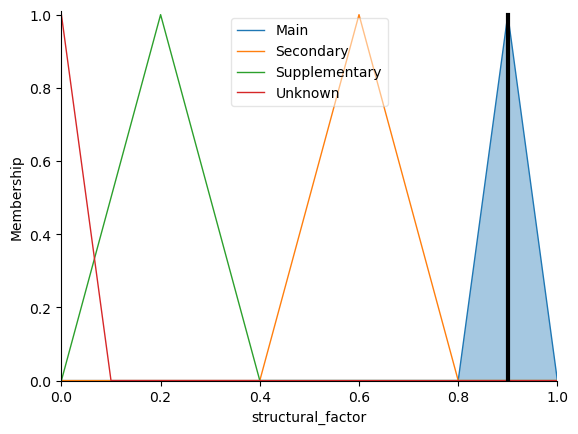

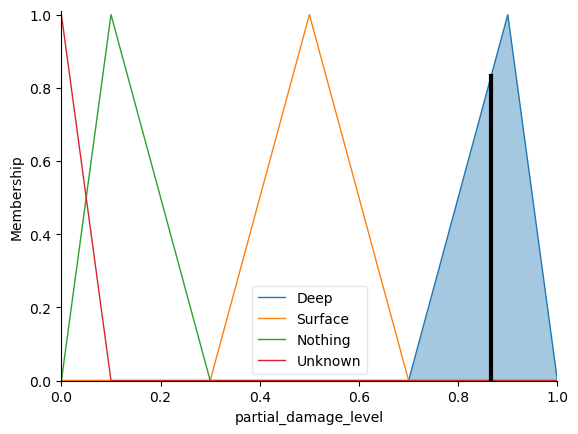

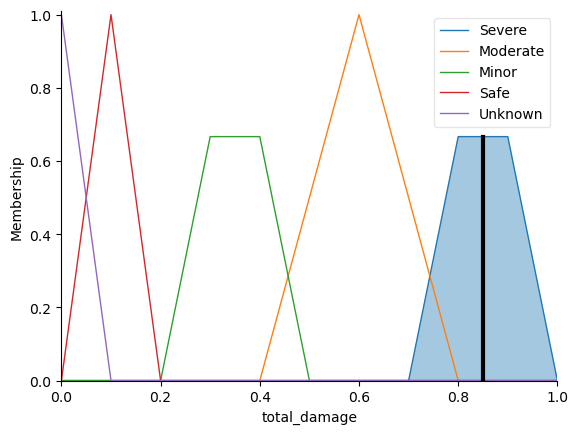

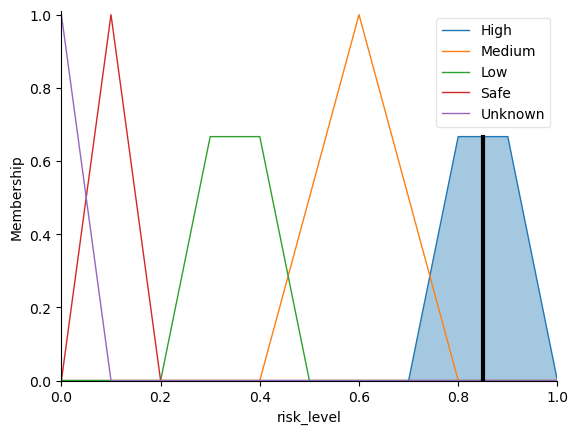

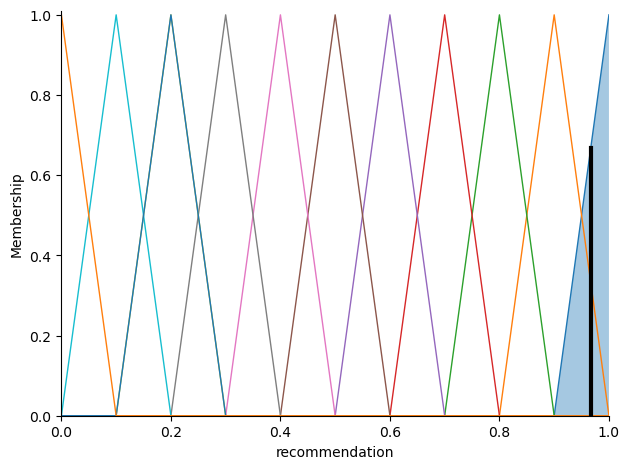

Fuzzy expert system executed successfully.


In [27]:
if __name__ == "__main__":
    print("Initializing the fuzzy expert system for post-war building assessments...")

    # Define linguistic variables
    variables = define_variables()
    (structural_safety, damage_type, repair_cost, repair_time, risk_factor, structural_factor, partial_damage_level, total_damage, risk_level, recommendation) = variables

    # Construct fuzzy rules
    rules = construct_rules(structural_safety, damage_type, repair_cost, repair_time, risk_factor, structural_factor, partial_damage_level, total_damage, risk_level, recommendation)

    # Create and simulate the fuzzy control system
    simulation = create_fuzzy_system(rules)
    simulation = evaluate_system(simulation)

    visualize_system(structural_factor, partial_damage_level, total_damage, risk_level, recommendation, simulation)
    print("Fuzzy expert system executed successfully.")